In [91]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from ydata_profiling import ProfileReport
import plotly.express as px

In [92]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
chronic_kidney_disease = fetch_ucirepo(id=336) 
  
# data (as pandas dataframes) 
X = chronic_kidney_disease.data.features # 24 independent features 
y = chronic_kidney_disease.data.targets # Target column 
  
# metadata 
print(chronic_kidney_disease.metadata) 
  
# variable information 
print(chronic_kidney_disease.variables) 

{'uci_id': 336, 'name': 'Chronic Kidney Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/336/data.csv', 'abstract': 'This dataset can be used to predict the chronic kidney disease and it can be collected from the hospital nearly 2 months of period.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 400, 'num_features': 24, 'feature_types': ['Real'], 'demographics': ['Age'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Mar 04 2024', 'dataset_doi': '10.24432/C5G020', 'creators': ['L. Rubini', 'P. Soundarapandian', 'P. Eswaran'], 'intro_paper': None, 'additional_info': {'summary': 'We use the following representation to collect the dataset\r\n                        age\t\t-\tage\t\r\n\t\t\tbp\t\t-\tblood pressure\r\n\t\t\tsg\t

On  target column: <br> - ckd means Chronic Kidney Disease <br>
                     - not ckd: means not Chronic Kidney Disease

In [93]:
import pandas as pd
chronic_kidney_disease # Get only the dataframe which exist inside the features value
# Take a copy of the original X
df = X.copy()

# Create a new column to y in order to have everything in one dataset
df['target'] = y
# Display the first five rows
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,target
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [95]:
print(df.columns)

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'target'],
      dtype='object')


In [96]:
df.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    object 
 6   pc      335 non-null    object 
 7   pcc     396 non-null    object 
 8   ba      396 non-null    object 
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    object 
 19  dm      398 non-null    object 
 20  cad     398 non-null    object 
 21  appet   399 non-null    object 
 22  pe

In [98]:
# check if there are duplicates in dataframe
df.duplicated().sum()

np.int64(0)

In [99]:
df.isna().sum()

age         9
bp         12
sg         47
al         46
su         49
rbc       152
pc         65
pcc         4
ba          4
bgr        44
bu         19
sc         17
sod        87
pot        88
hemo       52
pcv        71
wbcc      106
rbcc      131
htn         2
dm          2
cad         2
appet       1
pe          1
ane         1
target      0
dtype: int64

Since these are clinical data we need to further investigate the null values.

In [100]:
# Copy the dataset 
df = df.copy()

# We need to rename the columns since we cannot understand what each column means
df.rename(columns={'bp': 'blood_press', 'sg': 'specific_gravity',
                   'al':'albumin','su':'sugar',
                   'rbc':'red_blood_cells','pc':'pus_cell',
                   'pcc':'pus_cell_clumps','ba':'bacteria',
                   'bgr':'blood_glucose_random','bu':'blood_urea','sc':'serum creatinine',
                   'sod':'sodium','pot':'potassium','hemo':'hemoglobin',
                   'pcv':'packed_cell_volume','wc':'white_blood_cell_cnt','rc':'red_blood_cell_cnt',
                   'htn':'hypertension','dm':'diabetes_mellitus','cad':'coronary_artery_disease',
                   'appet':'appetite','pe':'pedal_edema','ane':'anemia', 'wbcc':'white_blood_cell_cnt', 'rbcc':'red_blood_cell_cnt',
                   'class':'class','target':'target'}, inplace=True)

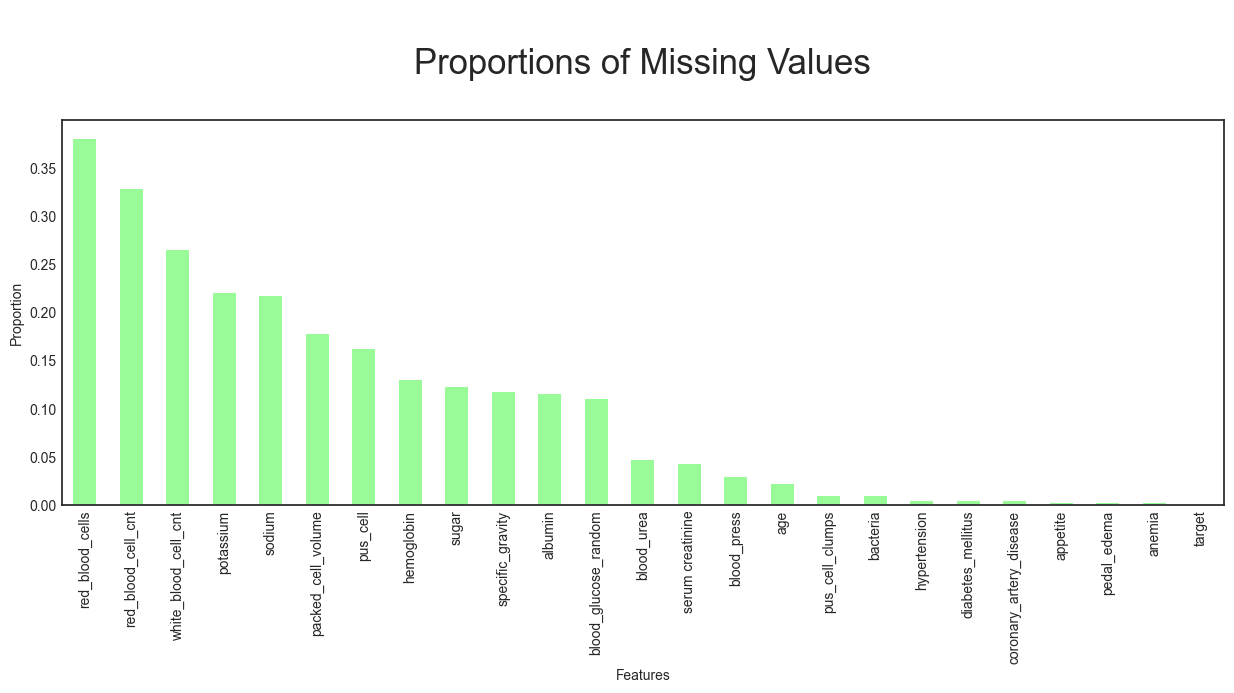

In [101]:
# missing values in ascending order 
missing = df.isna().sum().sort_values(ascending = False)

# plot the proportion of missing values
plt.figure(figsize=(15,5))
(missing/400).plot(kind="bar", color="palegreen") # we divide by 400 hundred to get only the proportion. (400 is the total records)
plt.title('\nProportions of Missing Values\n', fontsize=25)
plt.ylabel("Proportion")
plt.xlabel("Features")
plt.show()


In [102]:
# Define the ordinal data
ordinal = ['specific_gravity','albumin','sugar']

# Split the rest data into categorical and numerical columns
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object' and (col not in ordinal)]

In [108]:
print(f'The lenght of the odinal list is: {len(ordinal)}\n')
print(f'The lenght of the categorical list is: {len(cat_cols)}\n')
print(f'The lenght of the continuous list is: {len(num_cols)}\n')

The lenght of the odinal list is: 3

The lenght of the categorical list is: 11

The lenght of the continuous list is: 11



In [109]:
df.head()

,age,blood_press,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_cnt,red_blood_cell_cnt,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,target
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


# Overview with ydata profiling

In [32]:
df.columns

Index(['age', 'blood_press', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum creatinine', 'sodium',
       'potassium', 'hemoglobin', 'packed_cell_volume', 'white_blood_cell_cnt',
       'red_blood_cell_cnt', 'hypertension', 'diabetes_mellitus',
       'coronary_artery_disease', 'appetite', 'pedal_edema', 'anemia',
       'target'],
      dtype='object')

In [33]:
columns = ['age', 'blood_press', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'hemoglobin', 'packed_cell_volume', 'white_blood_cell_cnt',
       'red_blood_cell_cnt', 'hypertension', 'diabetes_mellitus',
       'coronary_artery_disease', 'appetite', 'pedal_edema', 'anemia',
       'target']

# Create a profile report
profile = ProfileReport(df, title="Kidney Disease Dataset Report", minimal=True)

# Display the profile report in a Jupyter notebook or JupyterLab
profile.to_notebook_iframe()

# Save the profile report to an HTML file
profile.to_file("kidney_disease_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 25/25 [00:00<00:00, 561.69it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#  Step 1: Univariate Analysis

We will look at each and every feature by itself without analyzing the relationships between the features.

# Categorical (Univariate)

In [111]:
# We created a function to get clear distribution of each caegorical variable
def summary(col):
    print(f"The distribution of {df[col].value_counts()}\n")
    print('------------------------')
    # Plot this distribution
    plt.figure(figsize=(6,4))
    label_counts = df[col].value_counts().reset_index()
    label_counts.columns = [col, 'Count']
    sns.barplot(data=label_counts, x=col, y='Count', hue= col,alpha=0.5)
    plt.ylabel('Amount of objects', fontsize=16)
    plt.xlabel('Class', fontsize=16)
    plt.title(f"{col} distribution")
    plt.tight_layout
    plt.show();
    # Total null values
    print(f"\nThe null values of {col} are: {df[col].isnull().sum()}")
    print('------------------------')

The distribution of red_blood_cells
normal      201
abnormal     47
Name: count, dtype: int64

------------------------


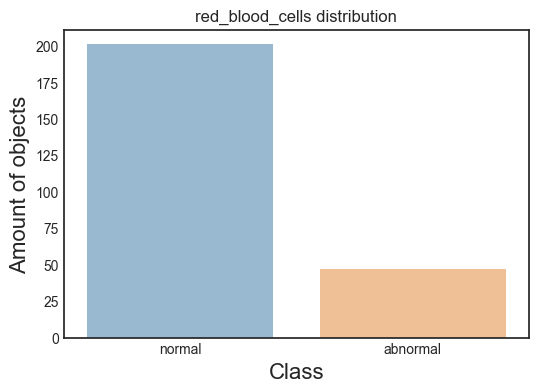


The null values of red_blood_cells are: 152
------------------------
The distribution of pus_cell
normal      259
abnormal     76
Name: count, dtype: int64

------------------------


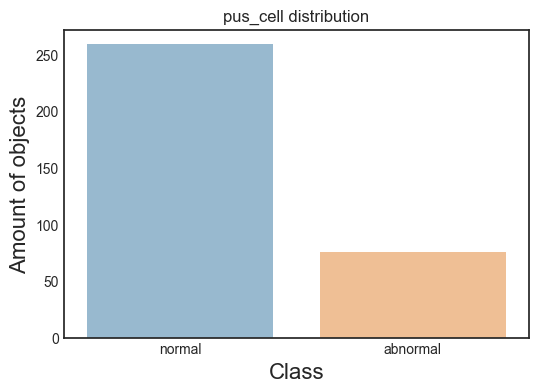


The null values of pus_cell are: 65
------------------------
The distribution of pus_cell_clumps
notpresent    354
present        42
Name: count, dtype: int64

------------------------


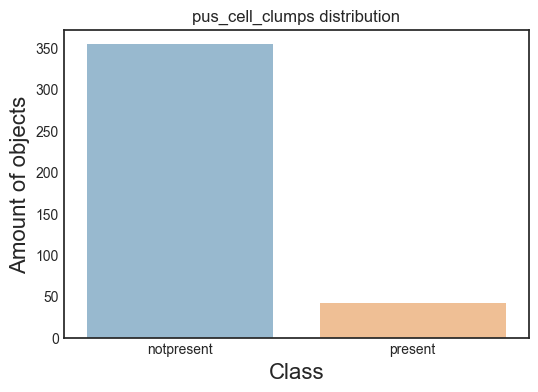


The null values of pus_cell_clumps are: 4
------------------------
The distribution of bacteria
notpresent    374
present        22
Name: count, dtype: int64

------------------------


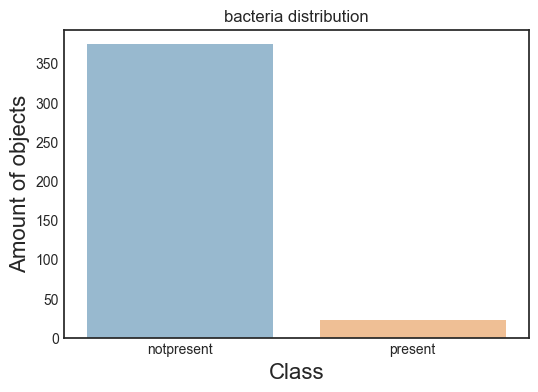


The null values of bacteria are: 4
------------------------
The distribution of hypertension
no     251
yes    147
Name: count, dtype: int64

------------------------


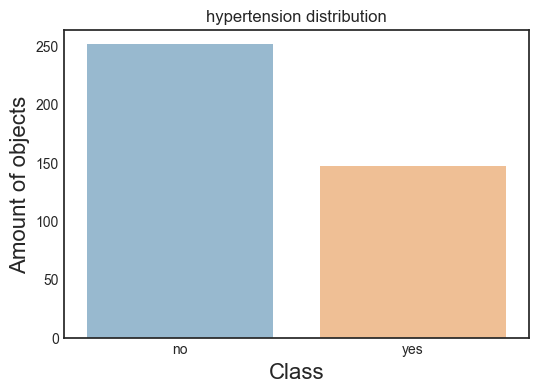


The null values of hypertension are: 2
------------------------
The distribution of diabetes_mellitus
no      260
yes     137
\tno      1
Name: count, dtype: int64

------------------------


d:\Big_Data_&_Analytics\Machine Learning and Algorithms\Μακλογιαννης\Kidney\Chronic-Kidney-Disease\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


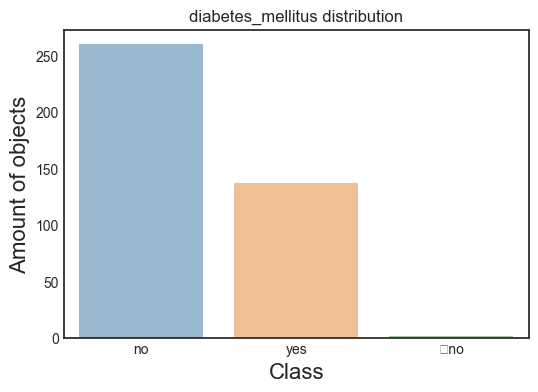


The null values of diabetes_mellitus are: 2
------------------------
The distribution of coronary_artery_disease
no     364
yes     34
Name: count, dtype: int64

------------------------


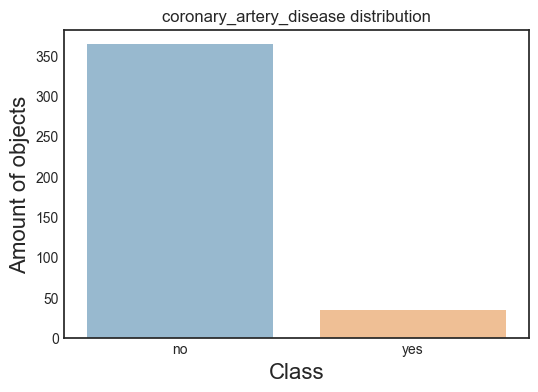


The null values of coronary_artery_disease are: 2
------------------------
The distribution of appetite
good    317
poor     82
Name: count, dtype: int64

------------------------


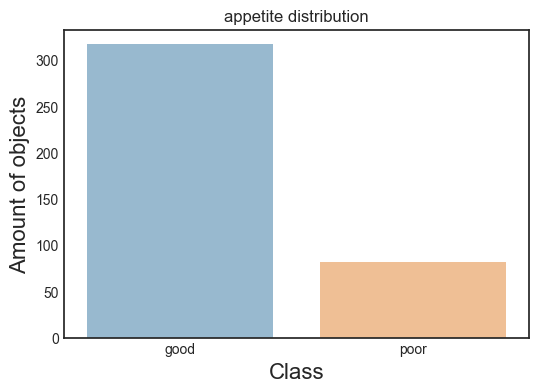


The null values of appetite are: 1
------------------------
The distribution of pedal_edema
no     323
yes     76
Name: count, dtype: int64

------------------------


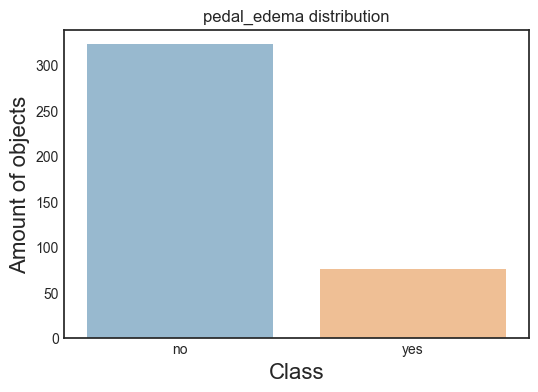


The null values of pedal_edema are: 1
------------------------
The distribution of anemia
no     339
yes     60
Name: count, dtype: int64

------------------------


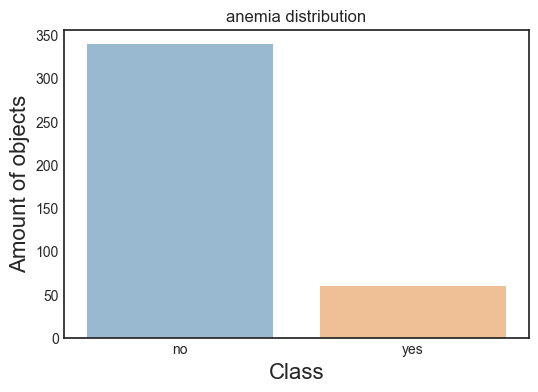


The null values of anemia are: 1
------------------------
The distribution of target
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

------------------------


d:\Big_Data_&_Analytics\Machine Learning and Algorithms\Μακλογιαννης\Kidney\Chronic-Kidney-Disease\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


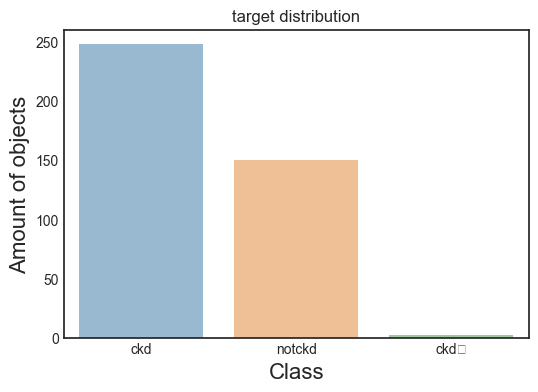


The null values of target are: 0
------------------------


In [112]:
for i in cat_cols:
    print('=============='*3)
    summary(i)
    print('=============='*3)

- As we can see on the 'target' has \t in ckd\t is just an extra tab character that was accidentally included in the dataset.

- The same for 'diabetes_mellitus'.

These are not part of the actual label, so it needs to be cleaned.

# Fix 'target'

In [113]:
df['target'].value_counts()

target
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

In [114]:
# Remove extra whitespace, including tabs, from the target column
df['target'] = df['target'].str.strip()
print(df['target'].value_counts())

target
ckd       250
notckd    150
Name: count, dtype: int64


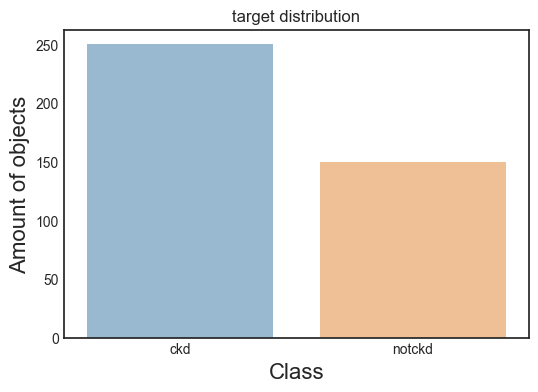

In [115]:
# Plot the target 's distribution
plt.figure(figsize=(6,4))
label_counts = df['target'].value_counts().reset_index()
label_counts.columns = ['target', 'Count']
sns.barplot(data=label_counts, x='target', y='Count', hue= 'target',alpha=0.5)
plt.ylabel('Amount of objects', fontsize=16)
plt.xlabel('Class', fontsize=16)
plt.title("target distribution")
plt.tight_layout
plt.show();

As we can see from the above the target classes are not equally distributed.

# Fix 'diabetes_mellitus'

In [116]:
df['diabetes_mellitus'].value_counts()

diabetes_mellitus
no      260
yes     137
\tno      1
Name: count, dtype: int64

In [117]:
# Remove extra whitespace, including tabs, from the target column
df['diabetes_mellitus'] = df['diabetes_mellitus'].str.strip()
print(df['diabetes_mellitus'].value_counts())

diabetes_mellitus
no     261
yes    137
Name: count, dtype: int64


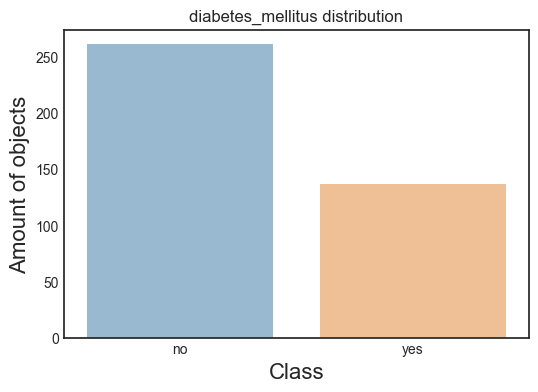

In [118]:
# Plot the target 's distribution
plt.figure(figsize=(6,4))
label_counts = df['diabetes_mellitus'].value_counts().reset_index()
label_counts.columns = ['diabetes_mellitus', 'Count']
sns.barplot(data=label_counts, x='diabetes_mellitus', y='Count', hue= 'diabetes_mellitus',alpha=0.5)
plt.ylabel('Amount of objects', fontsize=16)
plt.xlabel('Class', fontsize=16)
plt.title("diabetes_mellitus distribution")
plt.tight_layout
plt.show();

# Ordinal (Univariate)

The distribution of specific_gravity
1.020    106
1.010     84
1.025     81
1.015     75
1.005      7
Name: count, dtype: int64

------------------------


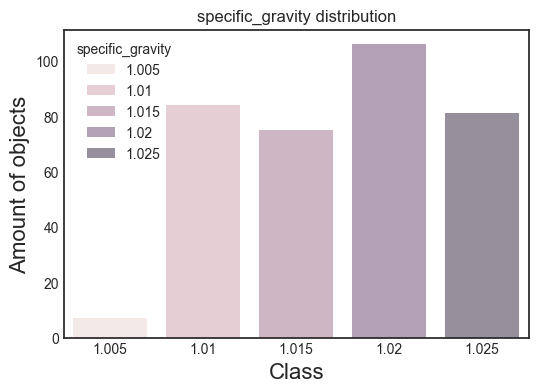


The null values of specific_gravity are: 47
------------------------
The distribution of albumin
0.0    199
1.0     44
3.0     43
2.0     43
4.0     24
5.0      1
Name: count, dtype: int64

------------------------


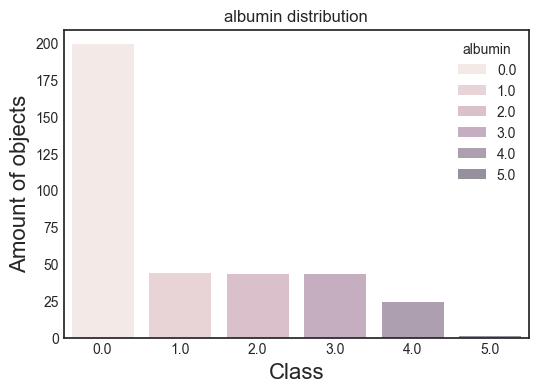


The null values of albumin are: 46
------------------------
The distribution of sugar
0.0    290
2.0     18
3.0     14
4.0     13
1.0     13
5.0      3
Name: count, dtype: int64

------------------------


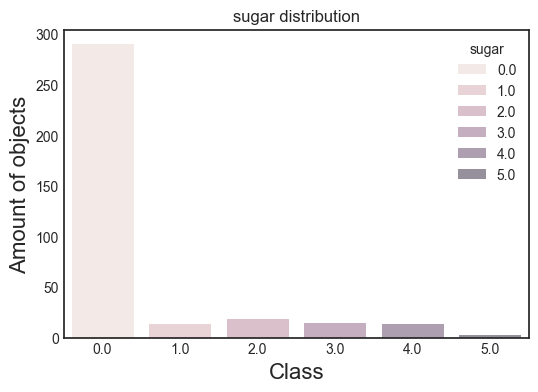


The null values of sugar are: 49
------------------------


In [110]:
for i in ordinal:
    print('=============='*3)
    summary(i)
    print('=============='*3)

- A blood sugar (glucose) test can show a result of 0 mg/dL (or 0 mmol/L), but this is extremely low and life-threatening, indicating severe hypoglycemia.
- An albumin level near zero indicates a severe condition called hypoalbuminemia, shows serious issues with the liver (making albumin), kidneys (leaking it out), severe malnutrition, inflammation, or gut absorption problems, leading to fluid leakage (edema) and weakness.

# Numerical Columns (Univariate)

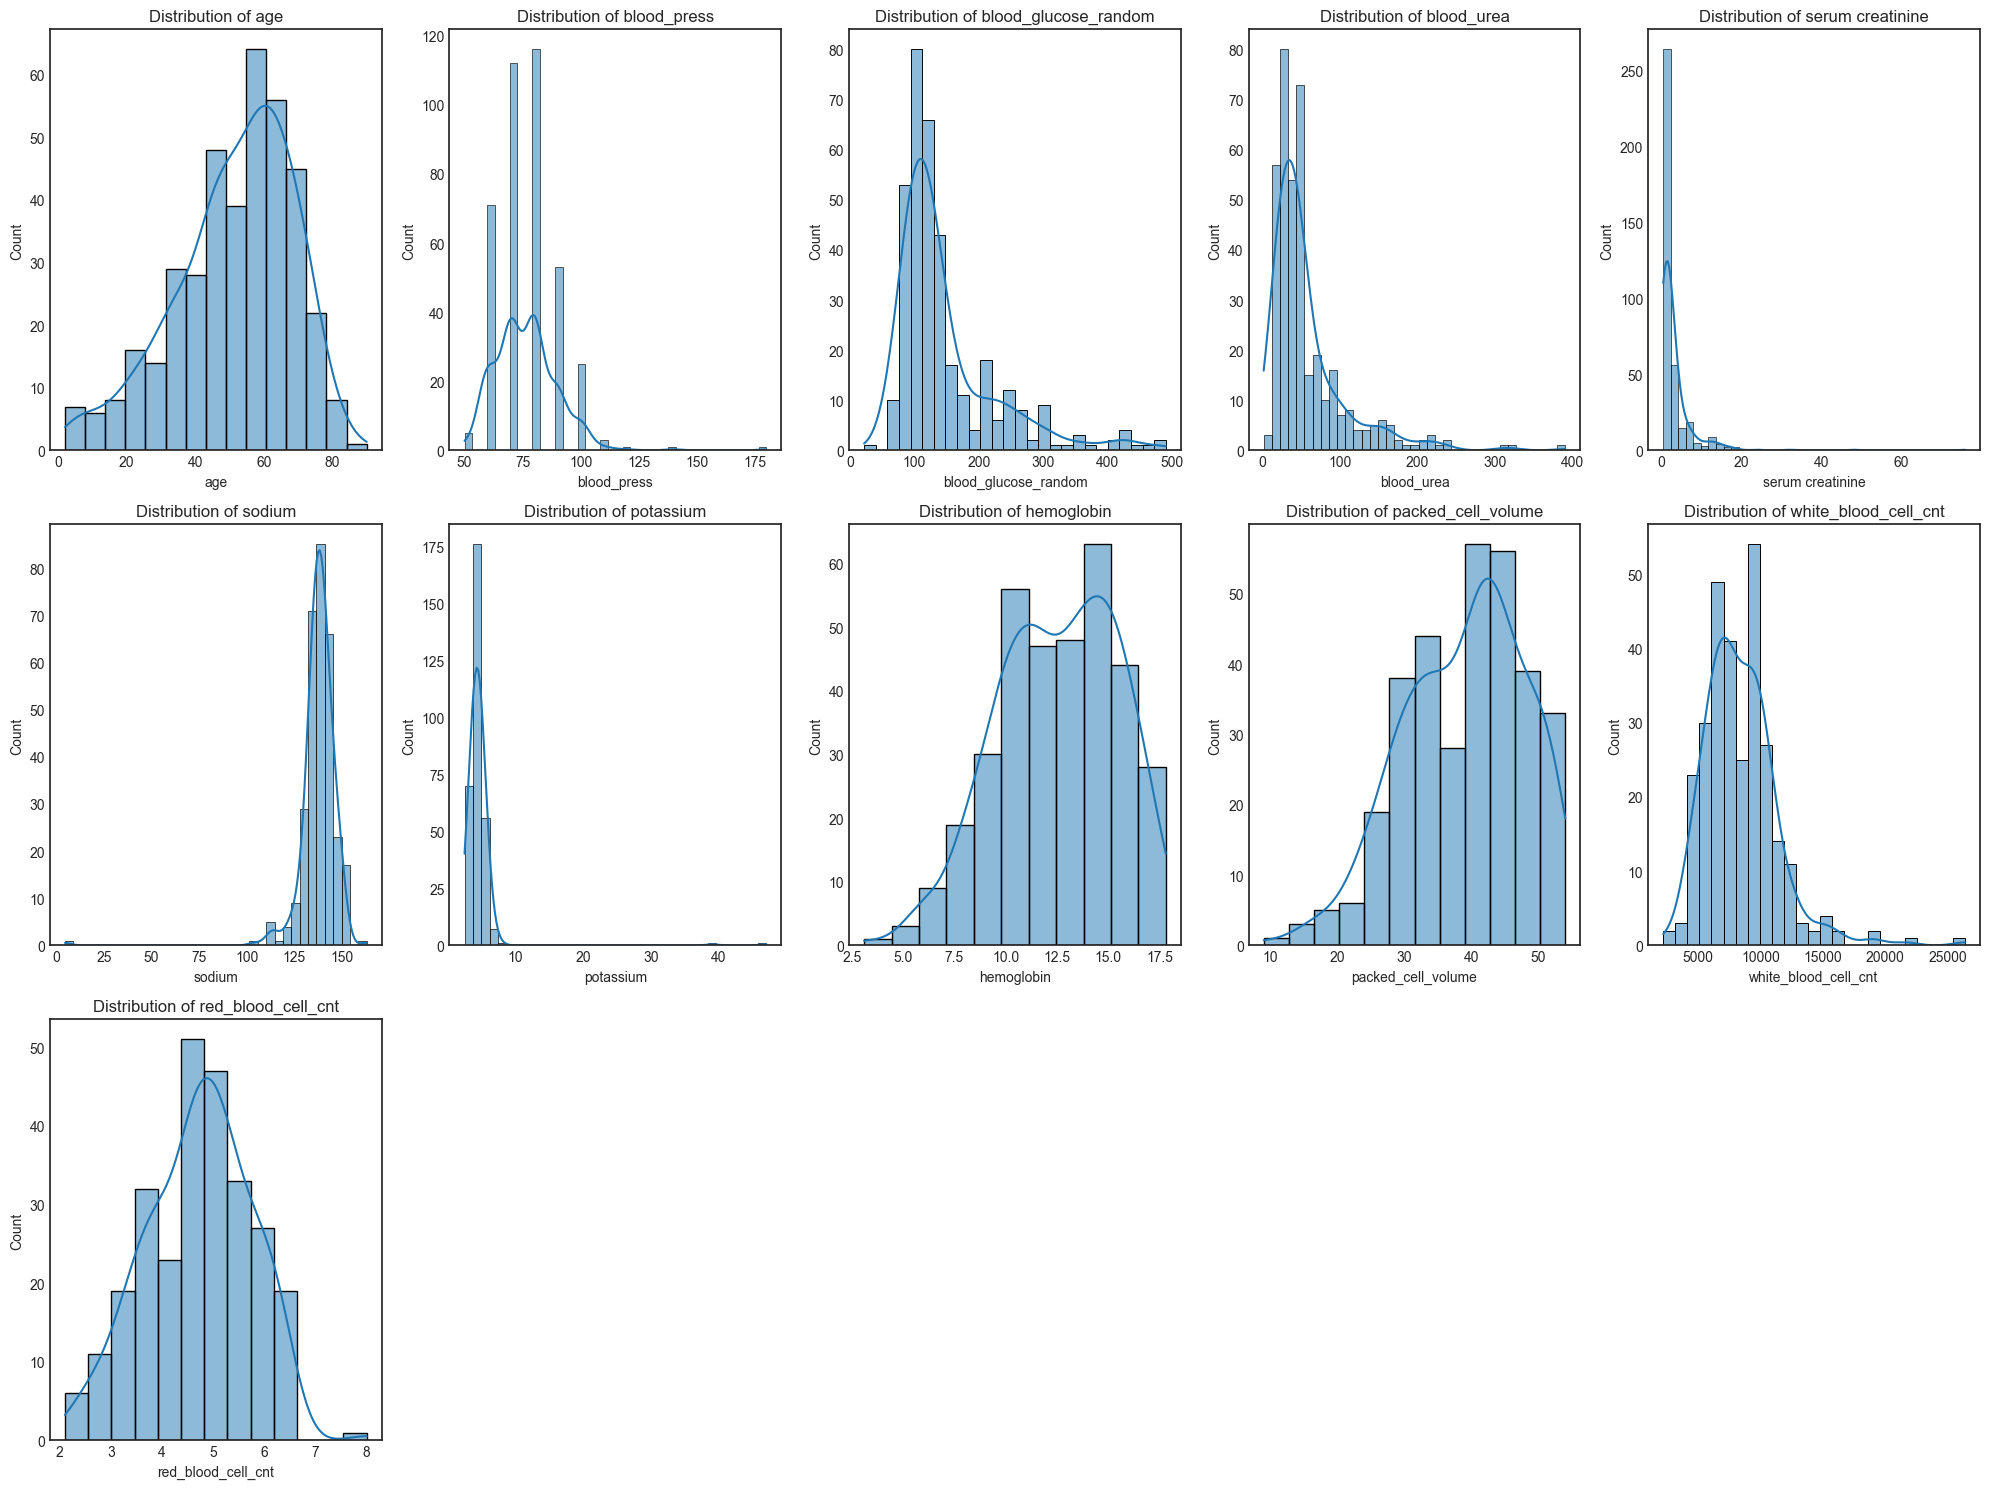

In [120]:
# checking numerical features distribution
plt.figure(figsize = (20, 15))
plotnumber = 1

for column in num_cols:
    if plotnumber <= 14:
        ax = plt.subplot(3, 5, plotnumber)
        sns.histplot(df[column],kde=True)
        plt.xlabel(column)
        plt.title(f'Distribution of {column}')
    plotnumber += 1

plt.tight_layout()
plt.show()

From the above diagram we can understand the follow:
- blood_urea is positive skewed. That means most of the values are clustered around the left tail of the distribution while the right tail is longer.

- serum_creatinine is highly positive skewed.The most data points are clustered in the left with a few high-value outliers on the right.

- sodium is highly negative skewed.

- potassium is highly positive skewed.

We will do further investigation for each and every variable.

In [121]:
# Create a function to plot each and every variable on univariate analysis
def dist_box(col):
    fig = plt.figure(figsize =(10, 7))
    fig, ax = plt.subplots(1,2, figsize = (15,5))
    sns.histplot(x= col, data = df, ax = ax[0],kde=True)
    sns.boxplot(x=col, data = df,color='purple',ax = ax[1])
    fig.suptitle(f'{col} Distribution', fontsize=16)
    plt.tight_layout()
    plt.show()

<Figure size 1000x700 with 0 Axes>

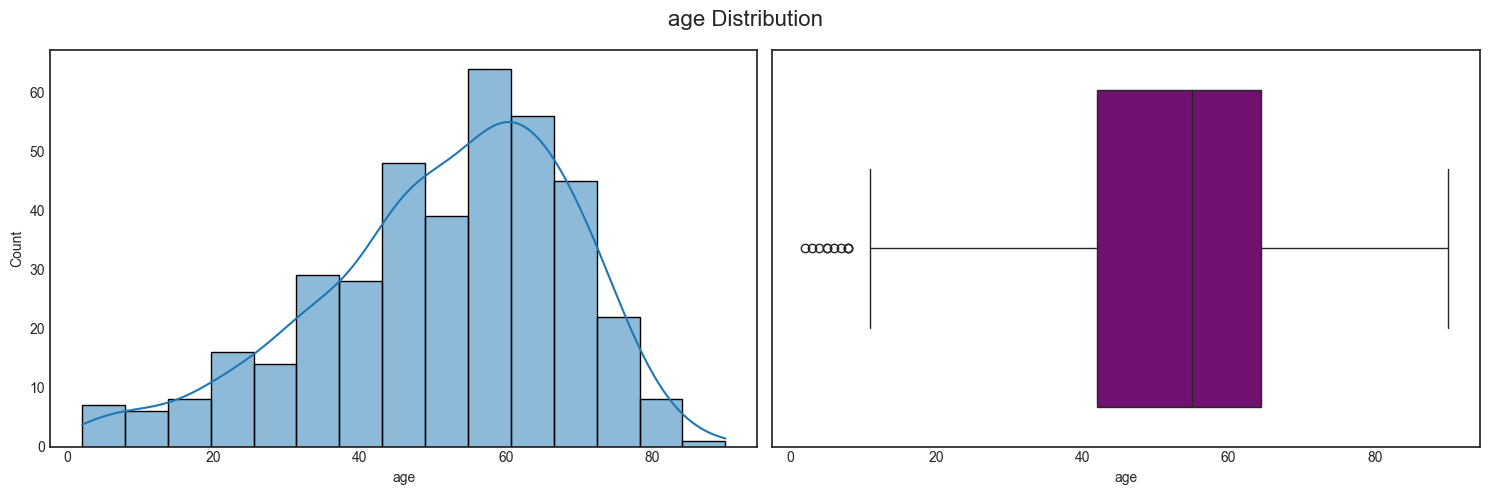

<Figure size 1000x700 with 0 Axes>

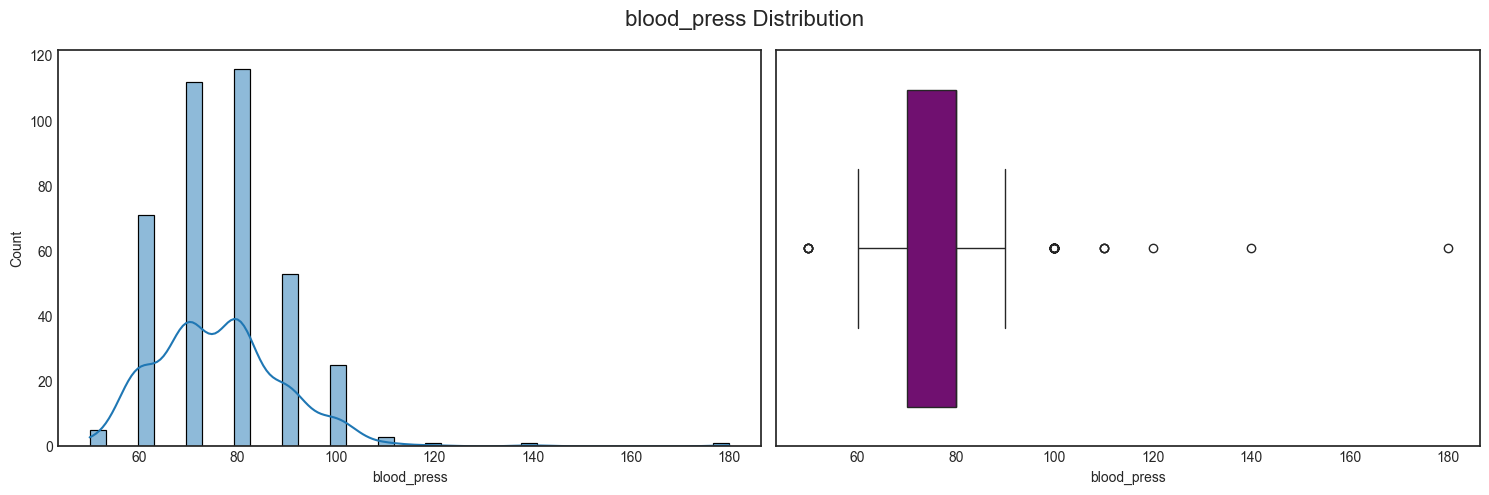

<Figure size 1000x700 with 0 Axes>

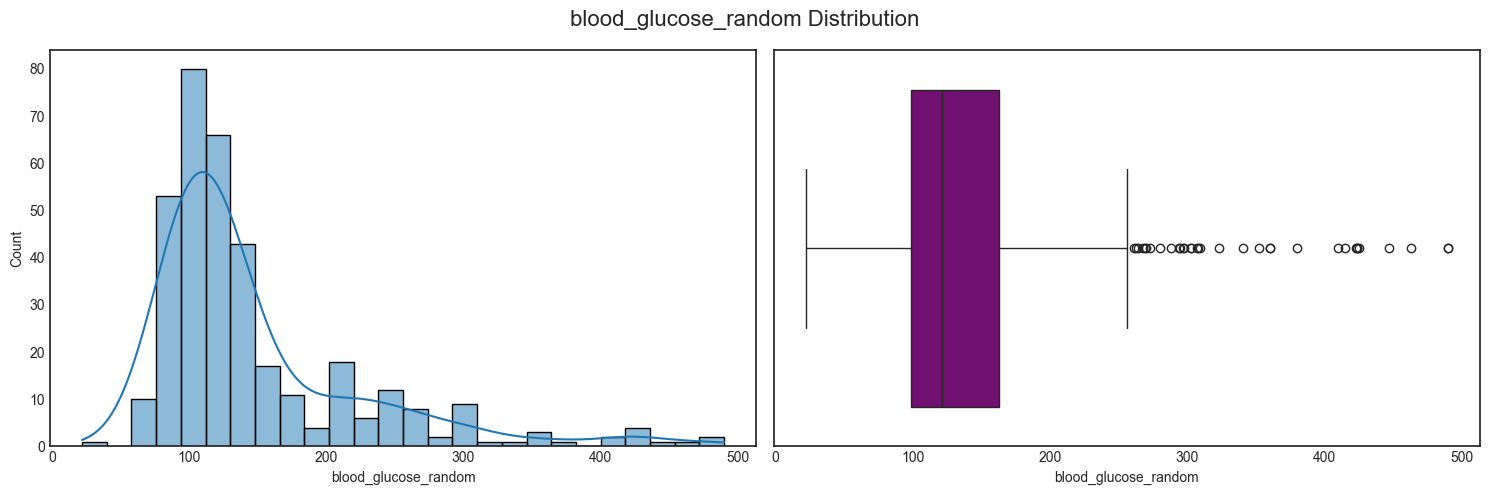

<Figure size 1000x700 with 0 Axes>

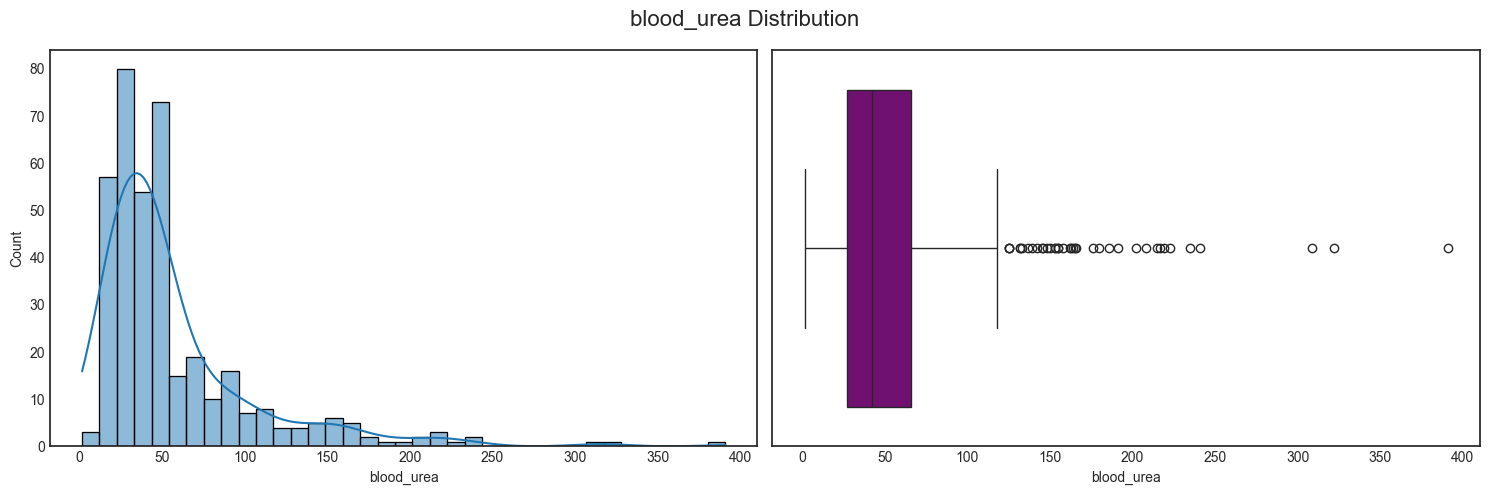

<Figure size 1000x700 with 0 Axes>

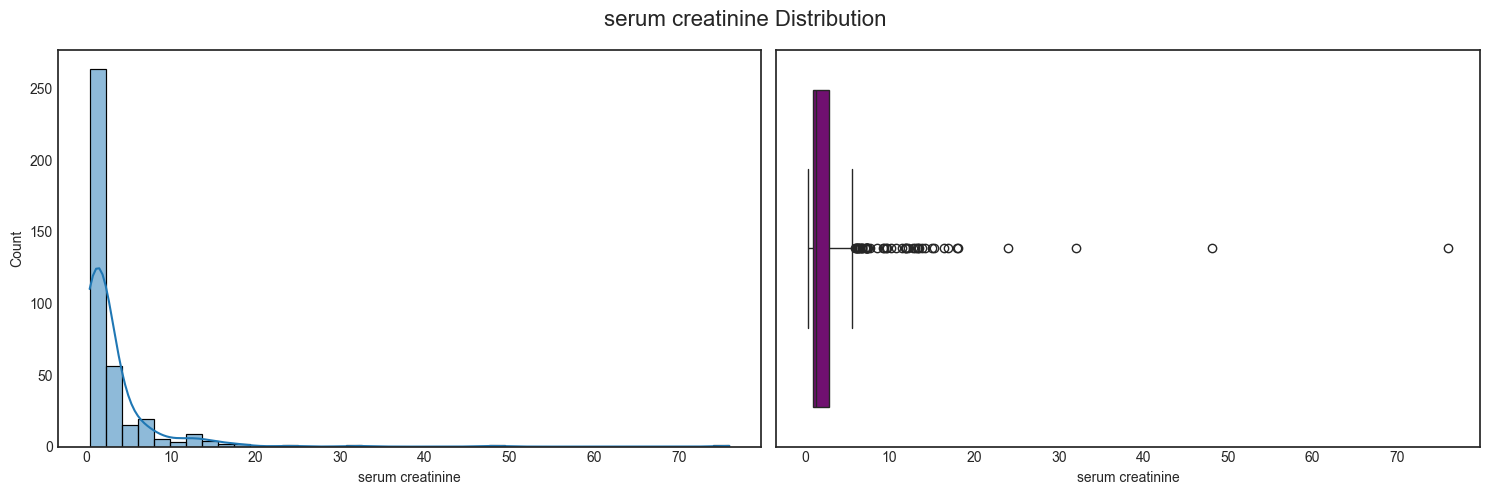

<Figure size 1000x700 with 0 Axes>

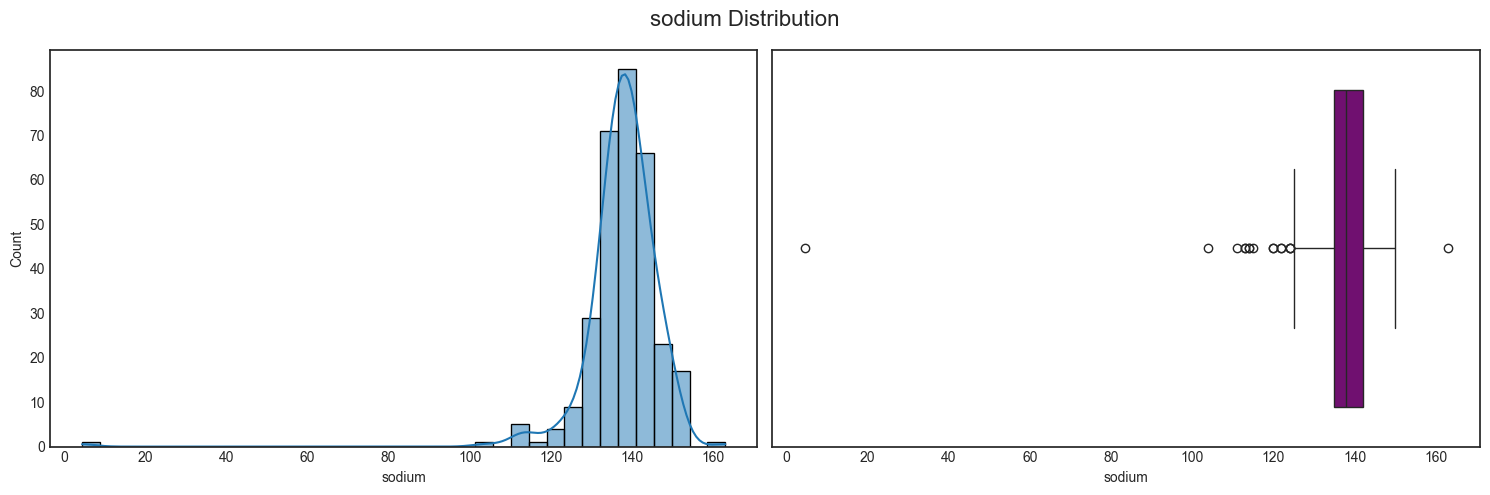

<Figure size 1000x700 with 0 Axes>

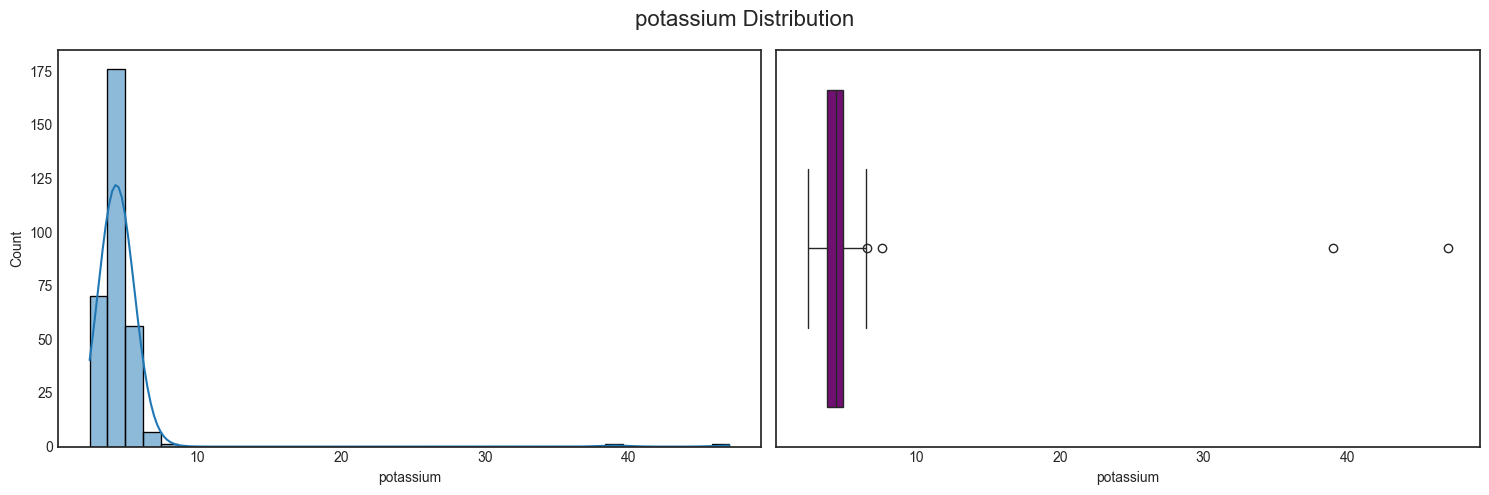

<Figure size 1000x700 with 0 Axes>

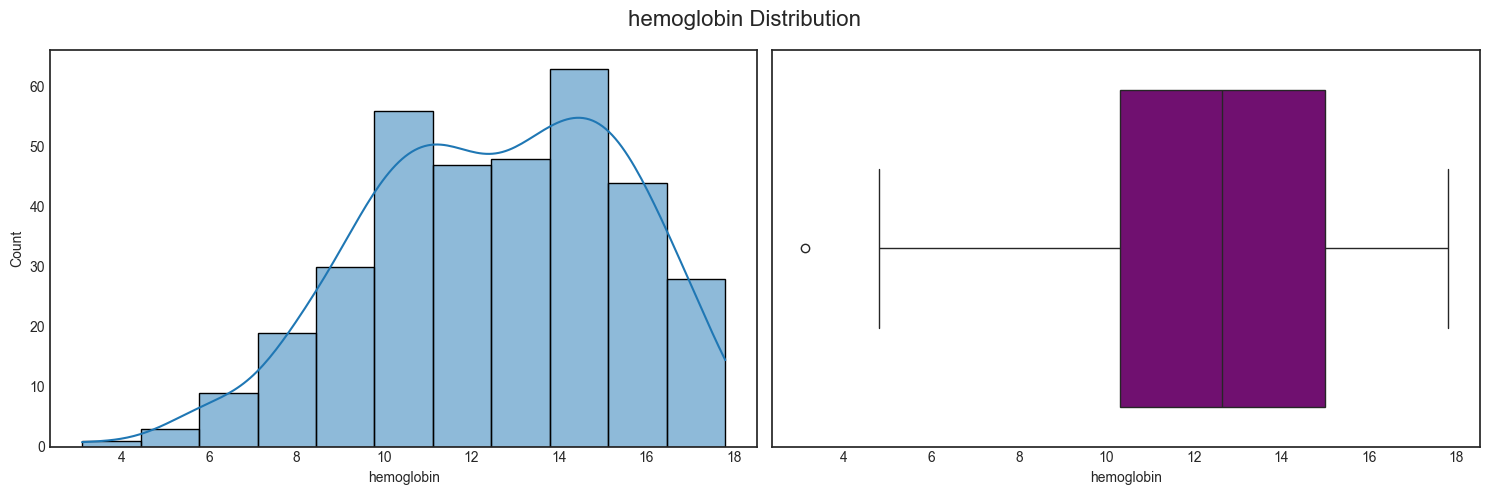

<Figure size 1000x700 with 0 Axes>

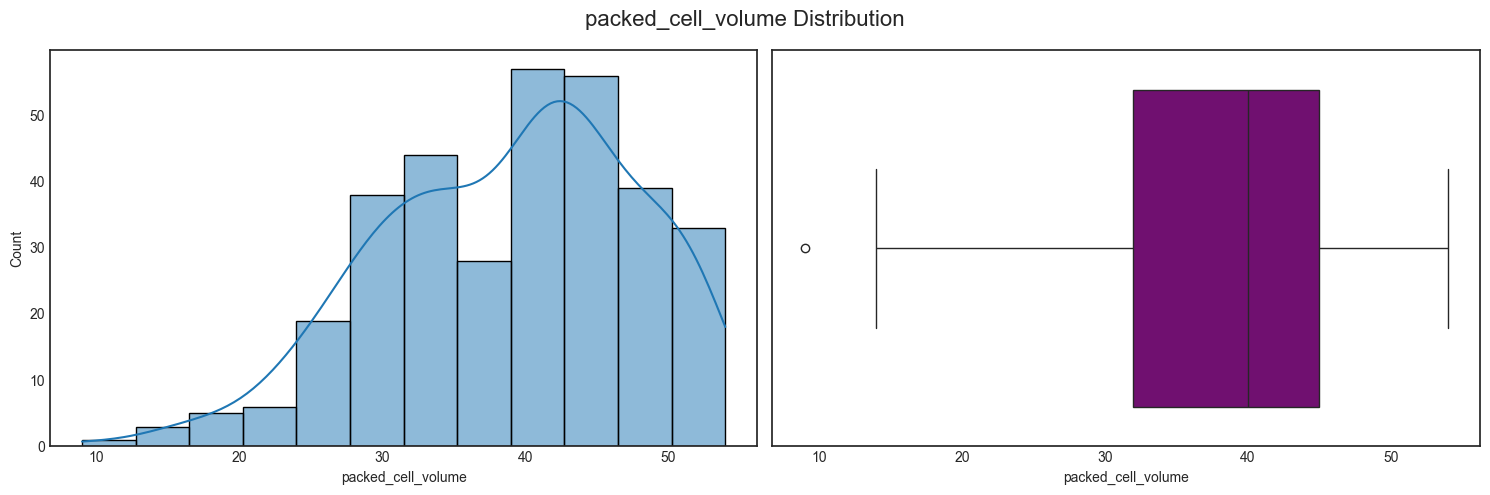

<Figure size 1000x700 with 0 Axes>

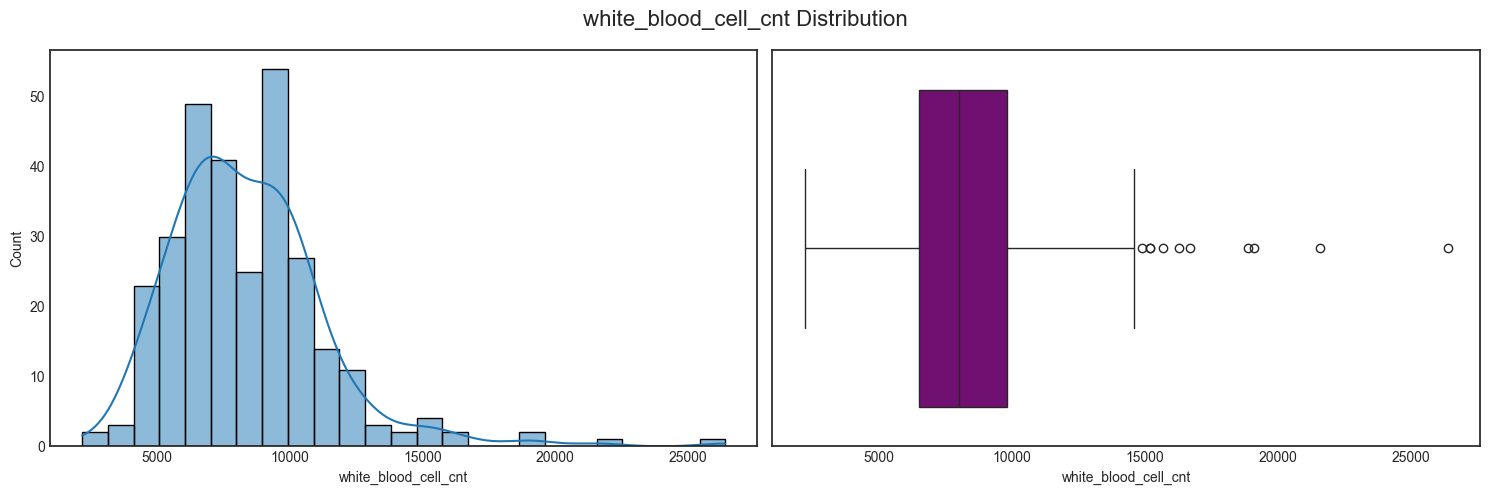

<Figure size 1000x700 with 0 Axes>

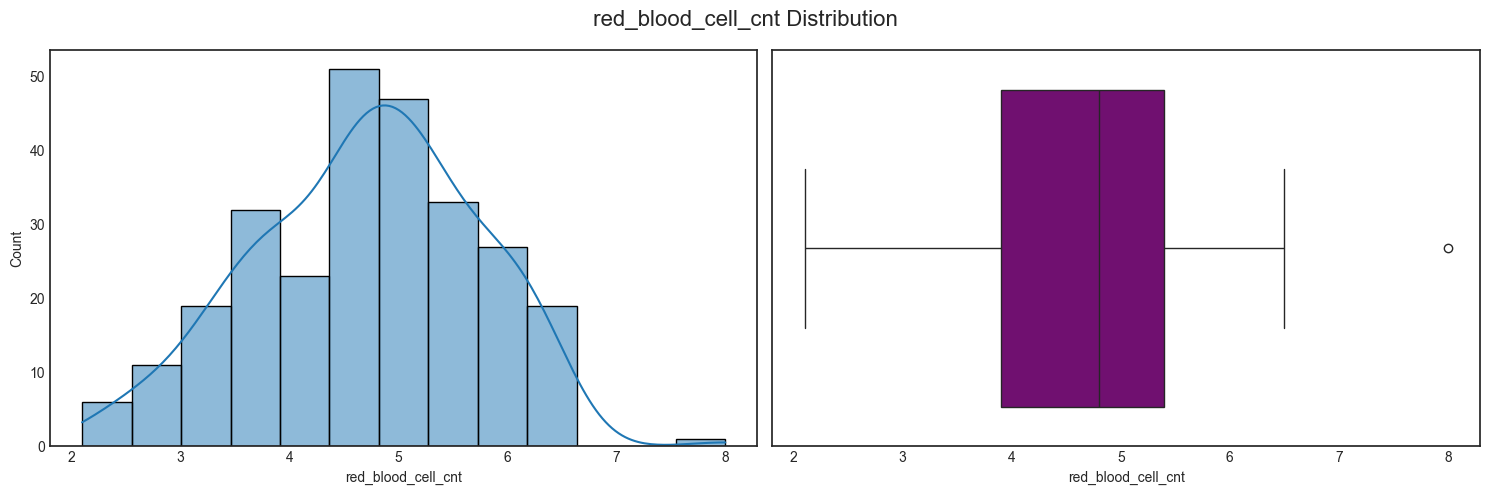

In [122]:
# use the above function for each and every continous variable
for i in num_cols:
    dist_box(i)

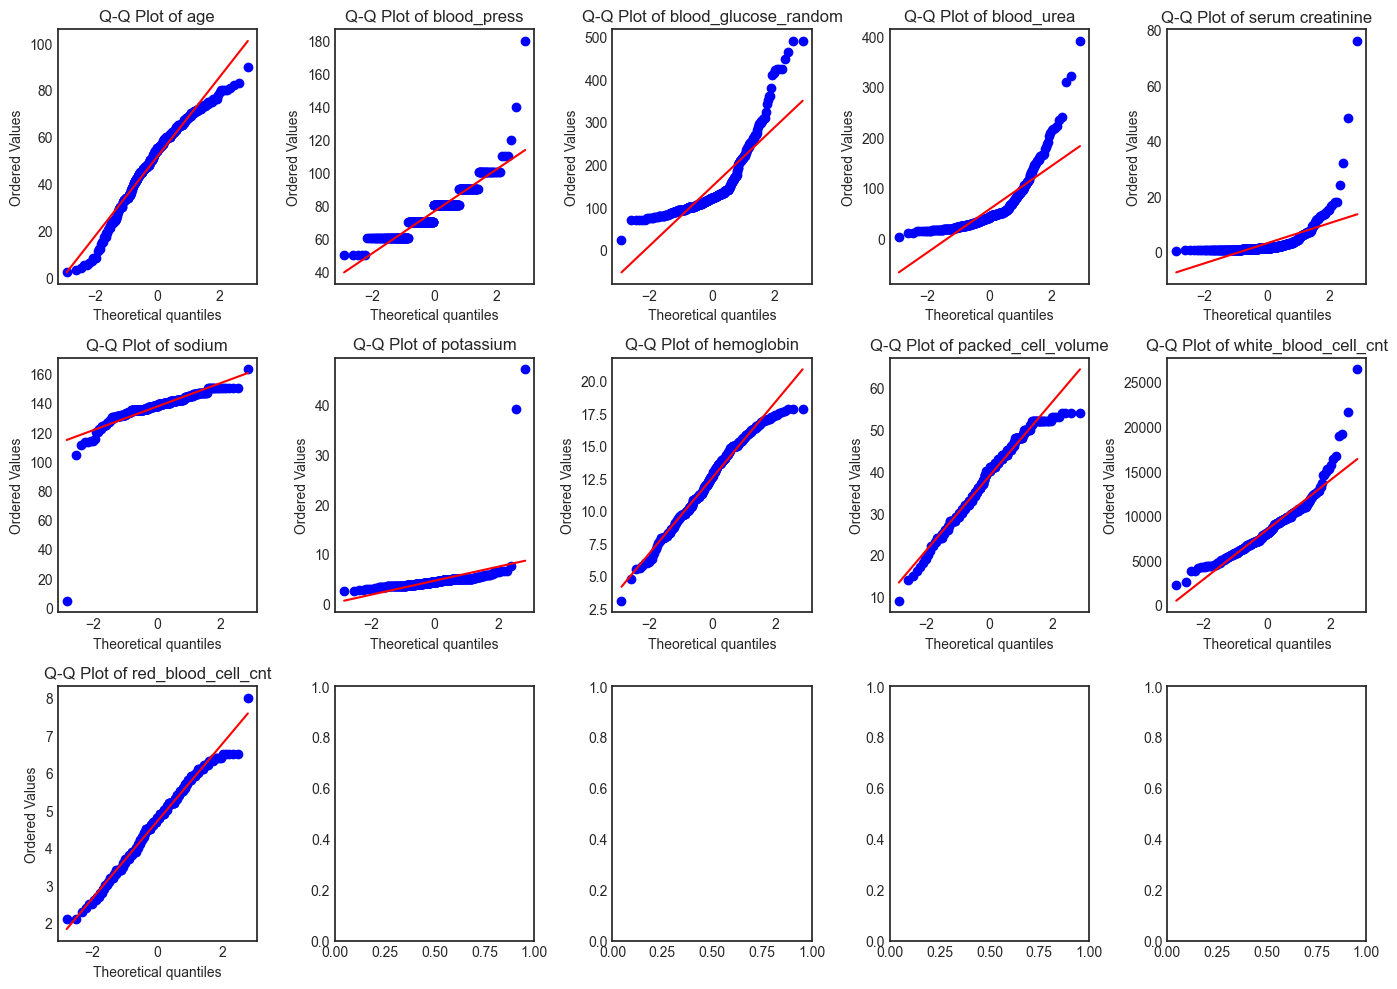

In [123]:
from scipy import stats
fig, axes = plt.subplots(3, 5, figsize=(14, 10))  #figures fig are the entire canvas. Axes are the single plots
axes = axes.flatten()  # axes is numpy array

for i,x in enumerate(num_cols):
    stats.probplot(df[x].dropna(), dist="norm", plot= axes[i])
    axes[i].set_title(f'Q-Q Plot of {x}')      
    plt.tight_layout()

# Distibution of numerical Data

- The Age Variable exhibits an approximately normal distribution centered around 55-60 years,<br> with a moderate spread and a small number of lower-end outliers.

- The blood pressure variable exhibits a right-skewed distribution with the majority of observations concentrated between 60 and 90. <br> There are several high-value outliers indicating extreme blood pressure.

- The box plot of blood_glucose_random shows a tight interquartile range (IQR) around the 100 mark, with several outliers scattered above 200,<br> indicating that there are a few instances with very high blood glucose values.

- Blood urea is positive skewed which means there are several high value outliers indicating extreme values of blood urea. The majority of observations <br> are concentrated between 10 and 60.

- Serum creatinine is highly positive skewed. Most observations are between 0.1 and 4 and also there are some extremely high values above 6.


- Sodium is approimately normal distributed with only few outliers. The observations are concentrated between 135-145.

- Potassium values are generally stable and consistent for most observations. A small number of extreme outliers dramatically increase the range.

- Hemoglobin 's distribution is approximately bell-shaped, suggesting hemoglobin values are fairly close to a normal distribution.<br> Most values fall between ~10 and 16, with the highest concentration around 12–14.There is a slight left skew, caused by a few lower hemoglobin values.

- The packed cell volume 's distribution is approximately normal, with a slight left skew and most of the values are concatenated between 30 and 50.

- The white blood cell 's are slightly right skewed with mose of observation concatenated between 6000 and 10000. There are only few records with <br> values over 14.000

- The red blood cells count is normaly distributed with only one outlier.

In [ ]:
# Define which categories with approximately normal distribution 
normality = ['age','blood_press','hemoglobin','packed_cell_volume','red_blood_cell_cnt','porassium']

# Define the highly skewed categories
skewned = ['blood_glucose_random','blood_urea','serum creatinine','sodium','potassium','white_blood_cell_cnt']

# Display the correlation matrix

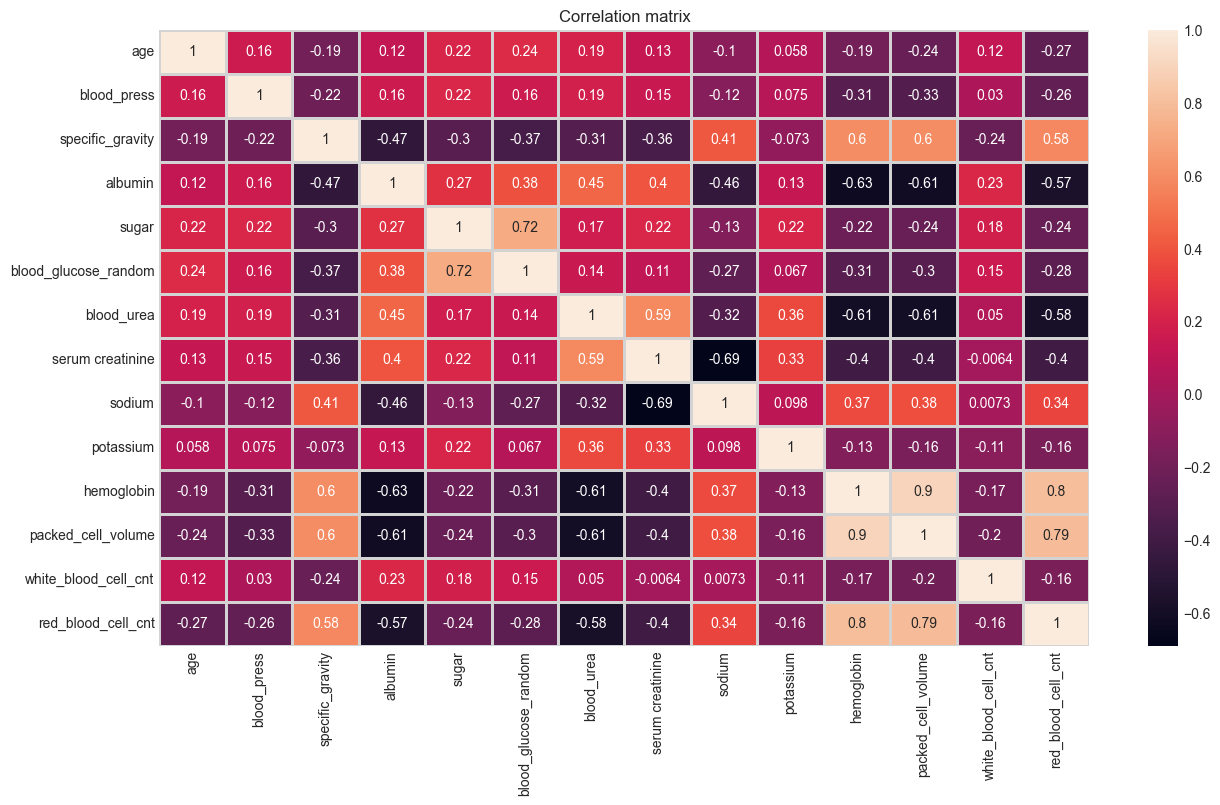

In [48]:
# Correlation matrix only for numerical data
plt.figure(figsize = (15, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot = True, linewidths = 2, linecolor = 'lightgrey')
plt.title('Correlation matrix')
plt.show()

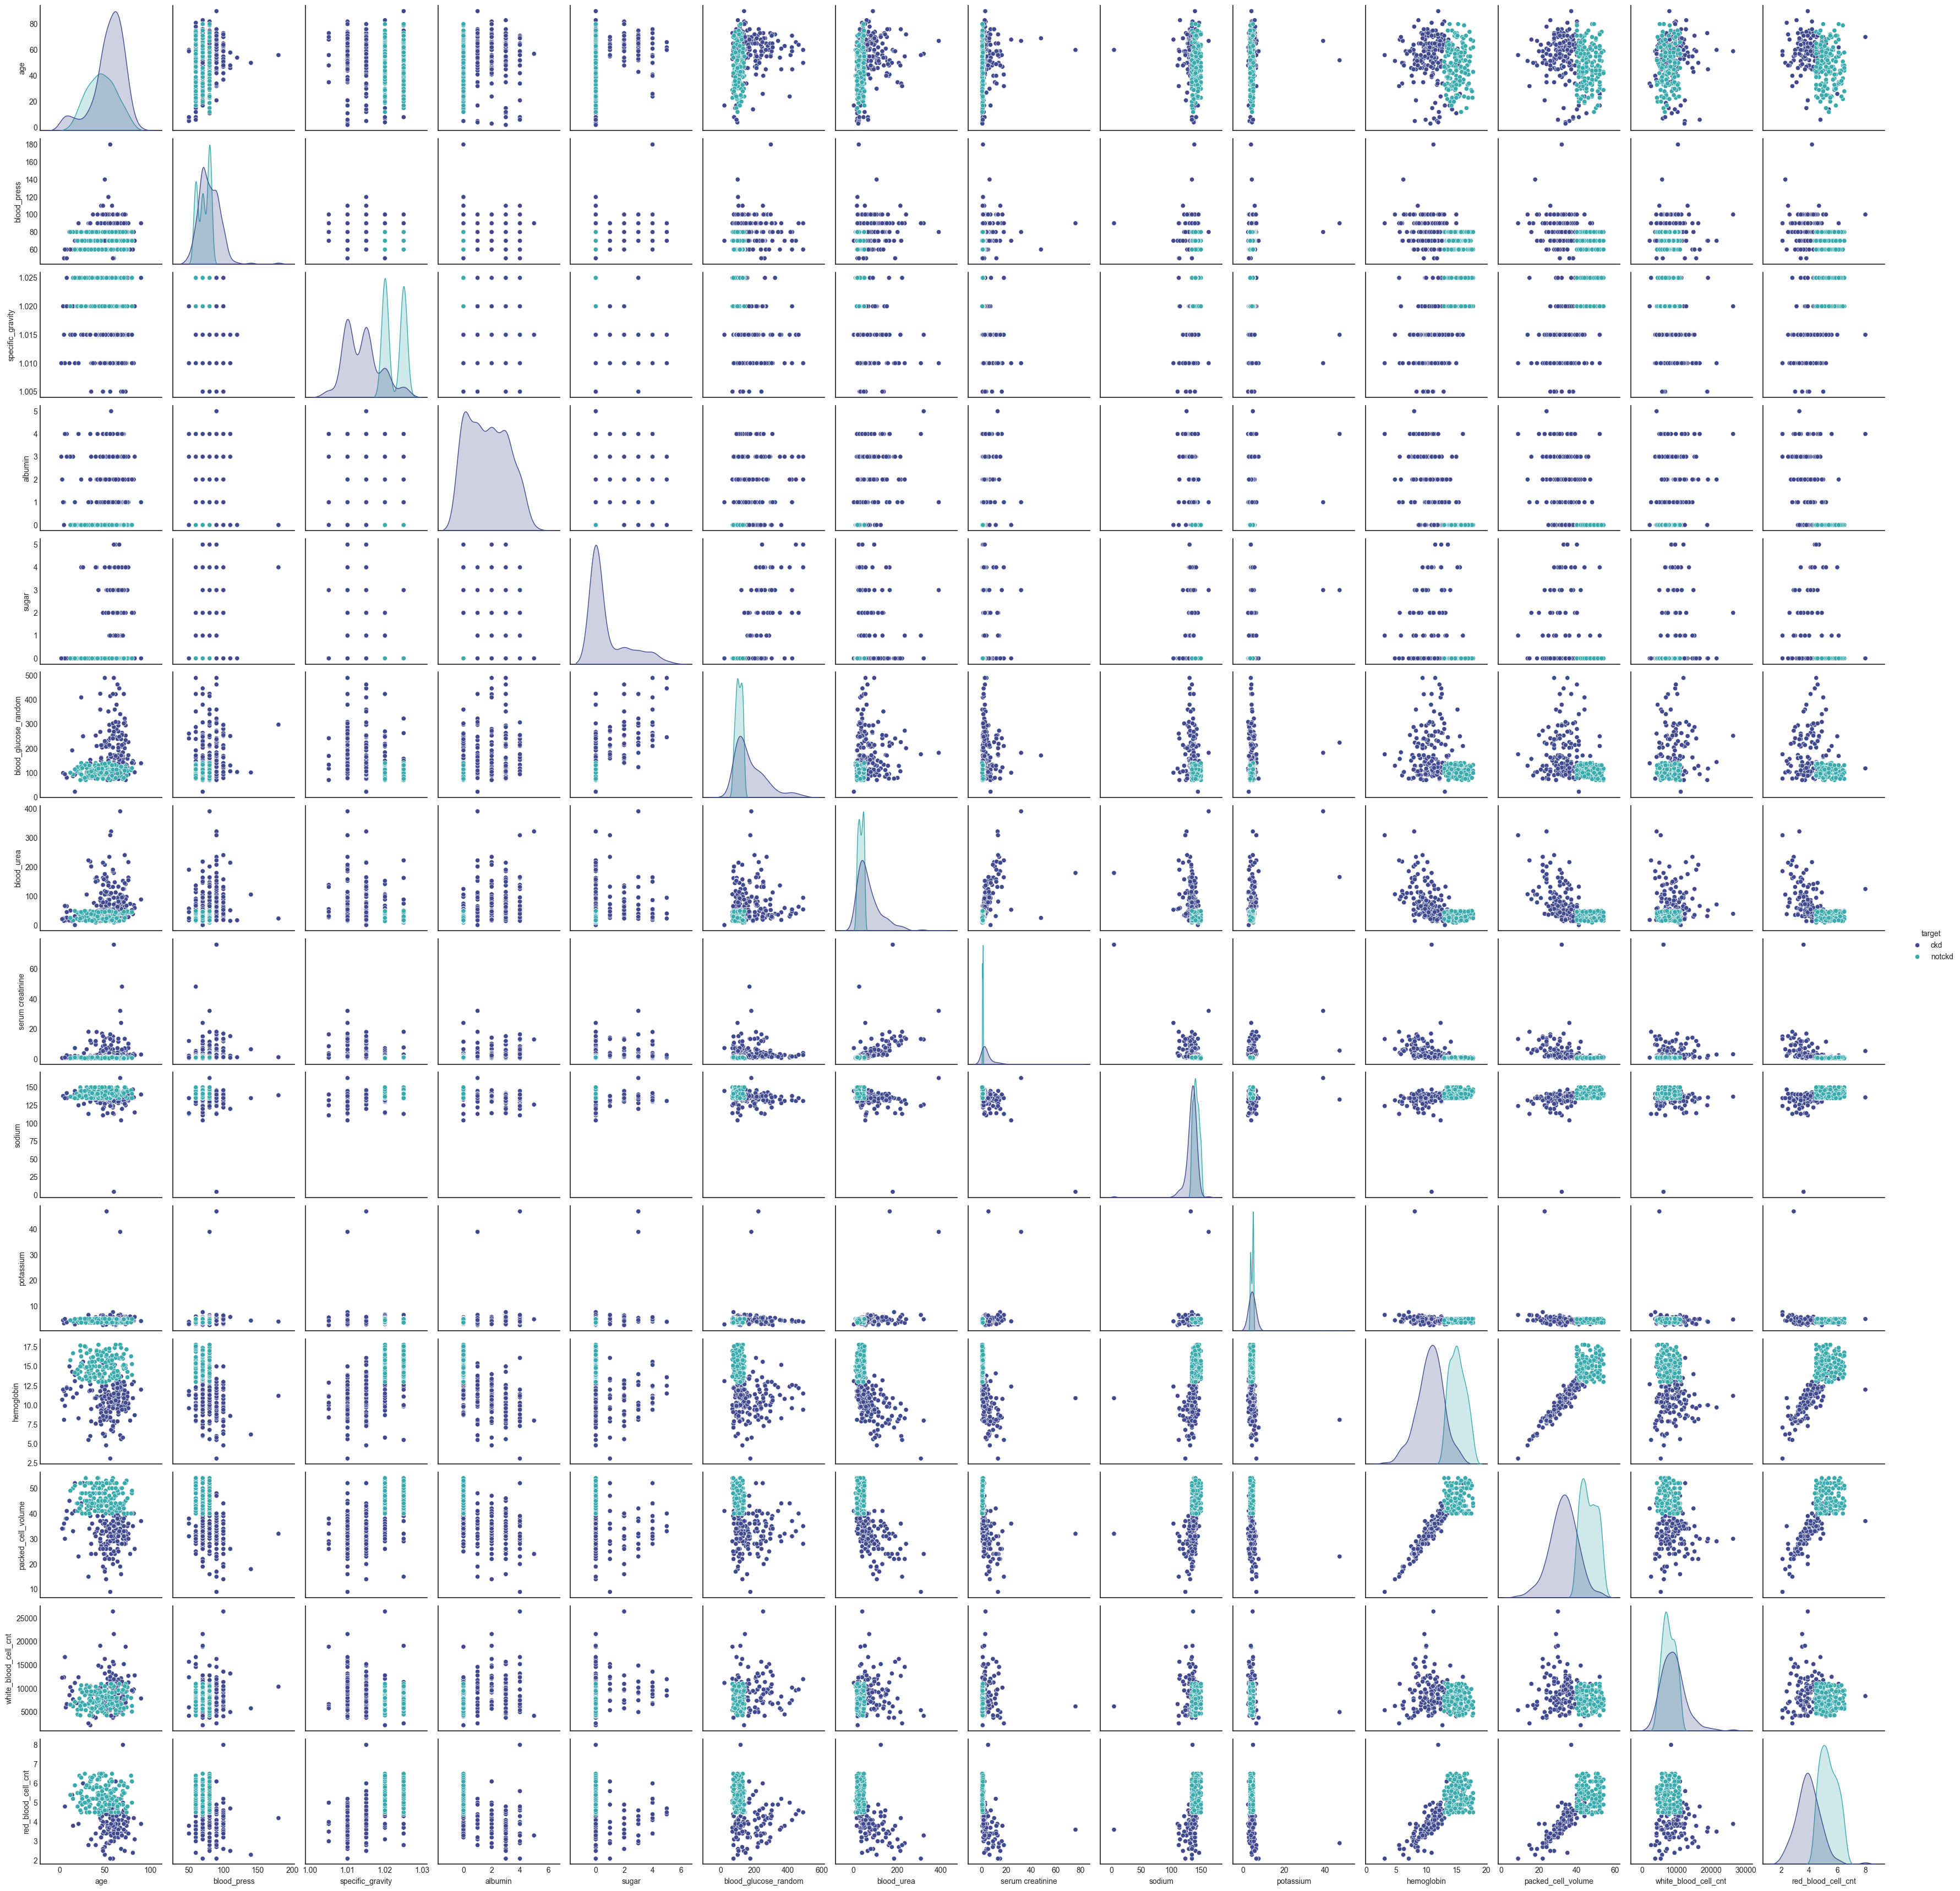

In [49]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-white')

# Drop 'person_id' and plot pairplot colored by sleep_disorder
sns.pairplot(data=df, 
             hue='target', 
             palette='mako')

plt.show()

# Feature Engineering

In [50]:
cat_cols

['red_blood_cells',
 'pus_cell',
 'pus_cell_clumps',
 'bacteria',
 'hypertension',
 'diabetes_mellitus',
 'coronary_artery_disease',
 'appetite',
 'pedal_edema',
 'anemia',
 'target']

In [51]:
df.head()

,age,blood_press,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_cnt,red_blood_cell_cnt,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,target
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [52]:
# Feature Encoding on the categorical Data.
# Since the categorical data have 2 categories 
# and since the labels can be ranked we will use the logic of label encoding.
# But since this algorithm encode by chance we will do this with map technique
custom_maps = {
    'red_blood_cells': {'normal': 0, 'abnormal': 1},
    'pus_cell': {'normal': 0, 'abnormal': 1},
    'pus_cell_clumps': {'notpresent': 0, 'present': 1},
    'bacteria': {'notpresent': 0, 'present': 1},
    'hypertension': {'no': 0, 'yes': 1},
    'diabetes_mellitus': {'no': 0, 'yes': 1},
    'coronary_artery_disease': {'no': 0, 'yes': 1},
    'appetite': {'good': 0, 'poor': 1},
    'pedal_edema': {'no': 0, 'yes': 1},
    'anemia': {'no': 0, 'yes': 1},
    'target': {'notckd': 0, 'ckd': 1}
}

for col, mapping in custom_maps.items():
    df[col] = df[col].map(mapping)


# Handle missing values

In [ ]:
# Calculate the amount of null values in each continuous column
df[num_cols].isnull().sum().sort_values(ascending = False)

red_blood_cell_cnt      131
white_blood_cell_cnt    106
potassium                88
sodium                   87
packed_cell_volume       71
hemoglobin               52
sugar                    49
specific_gravity         47
albumin                  46
blood_glucose_random     44
blood_urea               19
serum creatinine         17
blood_press              12
age                       0
dtype: int64

In [55]:
# Calculate the amount of null values in each Categorical column
df[cat_cols].isnull().sum().sort_values(ascending = False)

red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
pedal_edema                  1
anemia                       1
target                       0
dtype: int64

- red_blood_cells has a lot of null values.

In [126]:
# Calculate the amount of null values for ordinal columns
df[ordinal].isnull().sum().sort_values(ascending = False)

sugar               49
specific_gravity    47
albumin             46
dtype: int64

We will fill all of these data with different techniques.


- For continuous data the columns which have approximately normal distribution (the list normality) we will impute the data with mean.

- For continous data the columns which are highly skewed (the list skewned) we will impute the data with median.

- For categorical data (except of the red_blood_cells) we will impute the data with mode.<br> As for the red_blood_cells we will impute it with random sampling method.

- For ordinal data we will impute these columns with mode.

All of these imputation Techniques will be implemented after the Train Test spliting in order to avoid data leakage.

# Split the data

In [ ]:
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from feature_engine.imputation import RandomSampleImputer

# Define the categories for the ColumnTransformer
median_col = [i for i in skewned if i not 'red_blood_cells']
random_sample_col = ['red_blood_cells']


# Define the independent and dependent variables.
X = df.drop('target', axis=1)
y = df['target']

# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42  # Train size is 80 %. Test size is 20%. 
        )

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('tnf1',SimpleImputer(strategy='mean'),normality),
        ('tnf2',SimpleImputer(strategy = 'median'),median_col),
        ('tnf3',RandomSampleImputer(), random_sample_col)
        ('tnf4',SimpleImputer(strategy = 'mode'), ordinal)
    ],
    remainder='passthrough'
)


# GridSearchCv to find the best discretization settings
gsc = GridSearchCV(preprocessor, params, cv=5, scoring='recall', n_jobs=-1) # n_jobs = -1 to use the whole CPU
gsc.fit(X_train, y_train)

Recall refers to the model’s ability to find all relevant instances. For example, in the case of a medical test for a disease, <br> recall tells us how many actual positive cases (patients with the disease) were correctly identified by the test. We will give more attention on this metric since false <br> negatives are more expensive than false positives (someone who has chonik kidney disease it is very costly to classified as not).

Instead the other with the other metrics:

Precision it is used when it's very important for positive predictions to be accurate.

Accuracy for model performance, should be used only in combination with other metrics.